# Auxiliary Logits Capacity - Real-Time Tracking Notebook
This notebook tracks the relationship between the number of auxiliary logits and cross-model accuracy.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ci_95(arr):
    if len(arr) < 2:
        return 0.0
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

cache_file = '../experiments/cache/aux_logits_capacity.json'
if os.path.exists(cache_file):
    with open(cache_file, 'r') as f:
        data = json.load(f)
else:
    print('Cache file not found yet.')
    data = {}

In [2]:
if data:
    records = []
    for key, val in data.items():
        m_ghost = int(key)
        for metric, arr in val.items():
            mean_val = np.mean(arr)
            err_val = ci_95(arr)
            records.append({'Auxiliary Logits': m_ghost, 'Metric': metric, 'Mean': mean_val, 'Error': err_val})
    df = pd.DataFrame(records)
    display(df)

,Auxiliary Logits,Metric,Mean,Error
0,1,Reference,0.10945,0.020278
1,1,Teacher,0.94358,0.001300
2,1,Student (aux. only),0.10945,0.020278
3,1,Student (all logits),0.91211,0.004782
4,1,Cross-model (aux. only),0.10945,0.020278
5,1,Cross-model (all logits),0.75397,0.036976
6,3,Reference,0.11446,0.015392
7,3,Teacher,0.94314,0.001095
8,3,Student (aux. only),0.56269,0.061796
9,3,Student (all logits),0.91482,0.003598


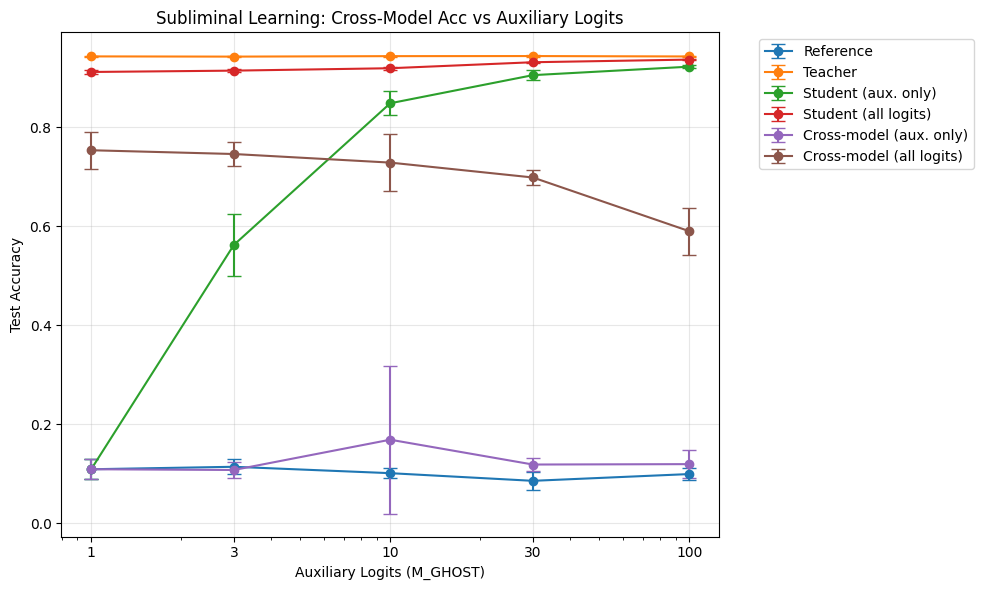

In [3]:
if data and 'df' in locals() and not df.empty:
    plt.figure(figsize=(10, 6))
    for metric in df['Metric'].unique():
        subset = df[df['Metric'] == metric].sort_values('Auxiliary Logits')
        plt.errorbar(subset['Auxiliary Logits'], subset['Mean'], yerr=subset['Error'], label=metric, marker='o', capsize=5)
    
    plt.xscale('log')
    plt.xticks([1, 3, 10, 30, 100], ['1', '3', '10', '30', '100'])
    plt.xlabel('Auxiliary Logits (M_GHOST)')
    plt.ylabel('Test Accuracy')
    plt.title('Subliminal Learning: Cross-Model Acc vs Auxiliary Logits')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()